#### Convert from output.out to raw

In [ ]:
import dpdata

sys = dpdata.LabeledSystem("output.out", fmt="siesta/aimd_output")
sys.to("deepmd/raw", "dataset_siesta_raw")

#### Convert from output.out to npy

In [ ]:
import dpdata

sys = dpdata.LabeledSystem("output.out", fmt="siesta/aimd_output")
sys.to("deepmd/npy", "dataset_siesta_npy")

#### Convert from npy to raw

In [ ]:
import dpdata

sys = dpdata.LabeledSystem("training_data", fmt="deepmd/npy")
sys.to("deepmd/raw", "dataset_raw")

#### Read log to visual data distribution

Total number of frames per folder:
Folder 10: 3948 frames
Folder 100: 5189 frames
Folder 112: 1000 frames
Folder 19: 4000 frames
Folder 28: 3403 frames
Folder 4: 7558 frames
Folder 52: 7765 frames
Folder 55: 7088 frames
Folder 58: 4089 frames
Folder 79: 8753 frames


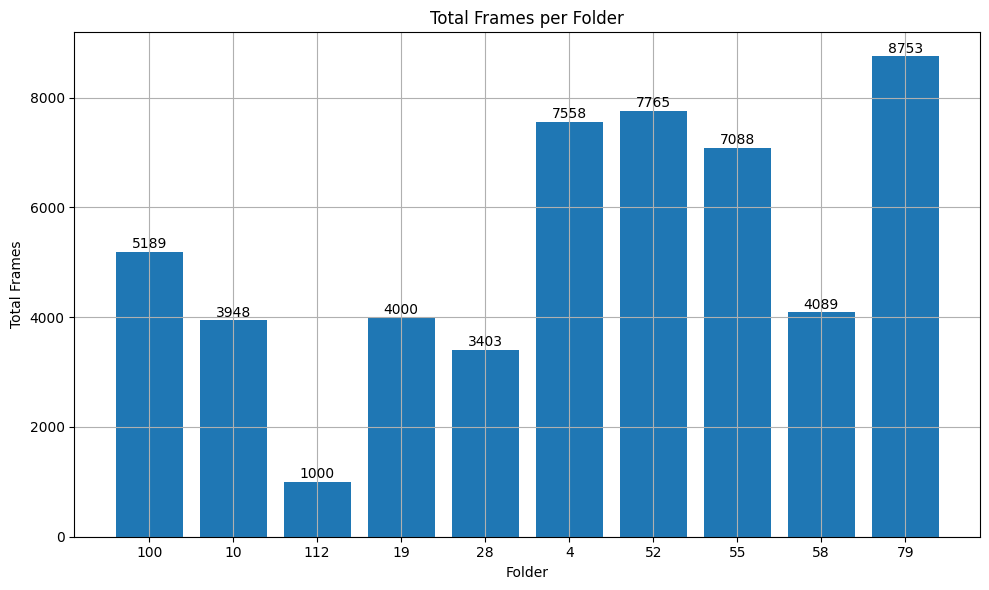

In [3]:
import re
import matplotlib.pyplot as plt
from collections import defaultdict

# List of folders to be analyzed
target_folders = {'4', '10', '19', '28', '52', '55', '58', "79", '100', '112'}
frame_counts = defaultdict(int)

# Read log file
with open(r'E:\Work Spaces\Thesis\Code\ThesisMaster\logs\2025-09-12_22-18-59\log.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Iterate through each line
for i in range(len(lines) - 1):
    line = lines[i].strip()

    # Match lines that contain input folder path
    match = re.search(r"input\\(\d+)", line)
    if match:
        folder_id = match.group(1)
        if folder_id in target_folders:
            next_line = lines[i + 1].strip()
            # Check if next line contains frame information
            frame_match = re.search(r"the data contains (\d+) frames", next_line)
            if frame_match:
                num_frames = int(frame_match.group(1))
                frame_counts[folder_id] += num_frames

# Print result
print("Total number of frames per folder:")
for folder in sorted(frame_counts):
    print(f"Folder {folder}: {frame_counts[folder]} frames")

# Plot distribution
plt.figure(figsize=(10, 6))
bars = plt.bar(frame_counts.keys(), frame_counts.values())

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 10, str(height),
             ha='center', va='bottom', fontsize=10)

plt.xlabel("Folder")
plt.ylabel("Total Frames")
plt.title("Total Frames per Folder")
plt.grid(True)
plt.tight_layout()
plt.show()
